In [ ]:
# 安装所需的 Python 包
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy', 'matplotlib', 'scipy'])
print('所有依赖包安装完成!')

所有依赖包安装完成！


# 第 3 章 参数估计


> **本章导读**: 抽样分布是已知参数推断统计量的分布; 参数估计反过来 -- 已知样本观测值推断未知参数的值. 本章系统介绍点估计(矩估计、极大似然估计、UMVUE)和评价标准(无偏性、有效性、C-R 下界).


---


## 3.1 矩估计


### 3.1.1 基本原理


矩估计(method of moments, MoM)的核心思想是: 用样本矩去估计总体矩, 从而解出参数估计值.


> 操作步骤:


> 1. 计算总体矩 EX^k(表示为参数的函数);


> 2. 令 EX^k = (1/n) sum X_i^k;


> 3. 解方程(组)得 theta_hat.


特殊情况: 当一阶矩 EX 不含有参数时, 可考虑使用一阶绝对矩 E|X| 代替.


In [3]:
# 代码演示:矩估计数值计算
import numpy as np
np.random.seed(42)
true_theta = 2.0
n = 100
sample = np.random.exponential(true_theta, n)
theta_hat = 1.0 / np.mean(sample)
print('真实参数: theta =', true_theta)
print('矩估计: theta_hat =', round(theta_hat, 4))
print('偏差:', round(theta_hat - true_theta, 4))

true_theta_la = 1.5
sample_la = np.random.laplace(0, true_theta_la, n)
theta_hat_la = np.mean(np.abs(sample_la))
print('Laplace: 真实 theta =', true_theta_la, ', 矩估计 =', round(theta_hat_la, 4))


真实参数: theta = 2.0
矩估计: theta_hat = 0.5466
偏差: -1.4534
Laplace: 真实 theta = 1.5 , 矩估计 = 1.4659


### 3.1.2 常见分布的矩估计


> 分布 (1) f(x)=(theta+1)x^theta, 0<x<1


EX = (theta+1)/(theta+2) => theta_hat = (2*X_bar-1)/(1-X_bar)


> 分布 (2) 指数分布 E(theta)


EX = 1/theta => theta_hat = 1/X_bar


> 分布 (3) Laplace 分布


EX=0 不含 theta, 改用一阶绝对矩: E|X| = theta => theta_hat = |X_bar|


> 分布 (4) 均匀分布 U[theta-0.5, theta+0.5]


EX = theta => theta_hat = X_bar


In [4]:
# 代码演示:多种分布的矩估计
import numpy as np
np.random.seed(42)
n=1000
true_theta=3.0
sample_u=np.random.uniform(true_theta-0.5,true_theta+0.5,n)
theta_hat_u=np.mean(sample_u)
print('均匀分布: 真实 theta =', true_theta, ', 矩估计 =', round(theta_hat_u,4))

true_mu,true_sigma=0.5,0.8
sample_ln=np.random.lognormal(true_mu,true_sigma,n)
log_x=np.log(sample_ln)
mu_hat=np.mean(log_x)
sigma2_hat=np.var(log_x,ddof=0)
print('对数正态: 真实 mu =', true_mu, ', 估计 =', round(mu_hat,4))
print('         真实 sigma2 =', round(true_sigma**2,4), ', 估计 =', round(sigma2_hat,4))


均匀分布: 真实 theta = 3.0 , 矩估计 = 2.9903
对数正态: 真实 mu = 0.5 , 估计 = 0.5791
         真实 sigma2 = 0.64 , 估计 = 0.6253


### 3.1.3 正态分布 P{X>1} 的矩估计


In [5]:
# 代码演示:正态分布 P{X>1} 的矩估计
import numpy as np
from scipy.stats import norm
np.random.seed(42)
true_mu,true_sigma=2,1.5
n=50
sample=np.random.normal(true_mu,true_sigma,n)
mu_hat=np.mean(sample)
sigma2_hat=np.var(sample,ddof=0)
p_hat=1-norm.cdf((1-mu_hat)/np.sqrt(sigma2_hat))
p_true=1-norm.cdf((1-true_mu)/true_sigma)
print('真实 P(X>1) =', round(p_true,4))
print('矩估计 P(X>1) =', round(p_hat,4))


真实 P(X>1) = 0.7475
矩估计 P(X>1) = 0.6834


---


## 3.2 极大似然估计


### 3.2.1 基本原理


极大似然估计(MLE)的核心思想是: 寻找使当前样本出现可能性最大的参数值.


操作步骤: 构造似然函数 L(theta)=prod f(x_i; theta), 取对数, 解似然方程.


MLE theta_hat = 0.5466


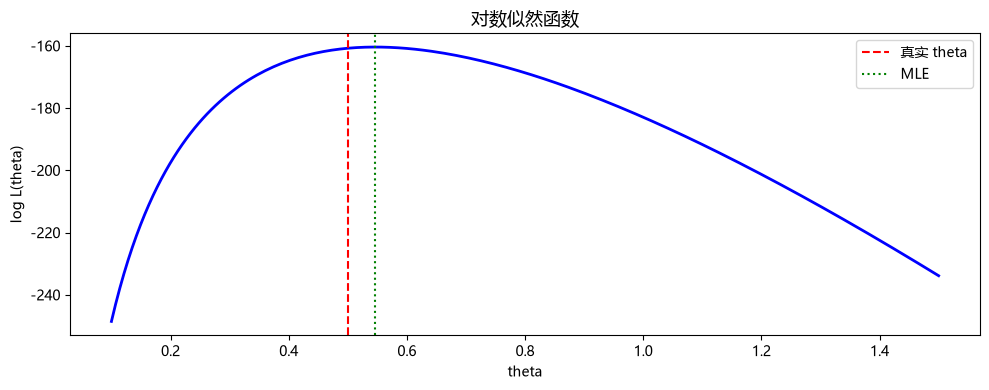

In [ ]:
# 代码演示:MLE 数值计算
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
true_theta=0.5
n=100
sample=np.random.exponential(1.0/true_theta,n)
theta_hat_mle=1.0/np.mean(sample)
print('MLE theta_hat =', round(theta_hat_mle,4))

thetas=np.linspace(0.1,1.5,200)
logL=np.zeros_like(thetas)
for i,th in enumerate(thetas):
    logL[i]=n*np.log(th)-th*np.sum(sample)
fig,ax=plt.subplots(figsize=(10,4))
ax.plot(thetas,logL,'b-',linewidth=2)
ax.axvline(true_theta,color='r',linestyle='--',label='真实 theta')
ax.axvline(theta_hat_mle,color='g',linestyle=':',label='MLE')
ax.set_title('对数似然函数',fontsize=13)
ax.set_xlabel('theta')
ax.set_ylabel('log L(theta)')
ax.legend()
plt.tight_layout()
plt.show()

### 3.2.2 常见分布的 MLE


> 指数分布 E(theta): theta_hat = 1/X_bar


> Laplace 分布: theta_hat = (1/n) sum |X_i|


### 3.2.3 正态分布的 MLE


mu_hat = X_bar, sigma2_hat = (1/n) sum (X_i - X_bar)^2


In [7]:
# 代码演示:正态分布的 MLE
import numpy as np
np.random.seed(42)
true_mu,true_sigma=5,2
n=50
sample=np.random.normal(true_mu,true_sigma,n)
mu_mle=np.mean(sample)
sigma2_mle=np.var(sample,ddof=0)
sigma2_unb=np.var(sample,ddof=1)
print('真实: mu =', true_mu, ', sigma2 =', true_sigma**2)
print('MLE: mu_hat =', round(mu_mle,4), ', sigma2_hat =', round(sigma2_mle,4))
print('无偏估计 S^2 =', round(sigma2_unb,4))


真实: mu = 5 , sigma2 = 4
MLE: mu_hat = 4.5491 , sigma2_hat = 3.4172
无偏估计 S^2 = 3.4869


---


## 3.3 无偏估计


若 E(theta_hat)=theta 对一切 theta 成立, 则称 theta_hat 是 theta 的无偏估计.


In [8]:
# 代码演示:无偏性的 Monte Carlo 验证
import numpy as np
np.random.seed(42)
true_mu,true_sigma=5,2
n=20
N_sim=50000
mu_hats=np.zeros(N_sim)
sigma2_mle=np.zeros(N_sim)
sigma2_unb=np.zeros(N_sim)
for i in range(N_sim):
    s=np.random.normal(true_mu,true_sigma,n)
    mu_hats[i]=np.mean(s)
    sigma2_mle[i]=np.var(s,ddof=0)
    sigma2_unb[i]=np.var(s,ddof=1)
print('X_bar 的模拟均值:', round(np.mean(mu_hats),4), '(理论:', true_mu, ')')
print('sigma2_MLE 的模拟均值:', round(np.mean(sigma2_mle),4), '(理论:', true_sigma**2, ') 有偏')
print('S^2 的模拟均值:', round(np.mean(sigma2_unb),4), '(理论:', true_sigma**2, ') 无偏')


X_bar 的模拟均值: 4.9968 (理论: 5 )
sigma2_MLE 的模拟均值: 3.8 (理论: 4 ) 有偏
S^2 的模拟均值: 4.0 (理论: 4 ) 无偏


---


## 3.4 UMVUE


### 3.4.1 Lehmann-Scheffe 定理


若 T 是 theta 的充分完备统计量, g(T) 是 theta 的无偏估计, 则 g(T) 是 UMVUE.


In [9]:
# 代码演示:正态分布 UMVUE
import numpy as np
np.random.seed(42)
true_mu,true_sigma=3,1.5
n=30
N_sim=20000
mu_umvue=np.zeros(N_sim)
for i in range(N_sim):
    s=np.random.normal(true_mu,true_sigma,n)
    mu_umvue[i]=np.mean(s)
print('X_bar 的模拟均值:', round(np.mean(mu_umvue),4), '(理论:', true_mu, ')')
print('X_bar 的模拟方差:', round(np.var(mu_umvue),4), '(理论:', round(true_sigma**2/n,4), ')')


X_bar 的模拟均值: 2.9979 (理论: 3 )
X_bar 的模拟方差: 0.076 (理论: 0.075 )


---


## 3.5 Fisher 信息量与 C-R 不等式


Fisher 信息量 I(theta) = E[(d/dtheta ln f)^2] = -E[d^2/dtheta^2 ln f]


In [10]:
# 代码演示:Fisher 信息量与 C-R 不等式
import numpy as np
from scipy.stats import norm
print('正态分布 N(mu,1): I(mu)=1, C-R 下界=1/n')
print('指数分布 E(lambda): I(lambda)=1/lambda^2, C-R 下界=lambda^2/n')
np.random.seed(42)
n=10000
true_mu=0
sample=np.random.normal(true_mu,1,n)
scores=sample-true_mu
fisher_numerical=np.mean(scores**2)
print('数值验证 N(0,1) Fisher 信息量:', round(fisher_numerical,4), '(理论: 1)')


正态分布 N(mu,1): I(mu)=1, C-R 下界=1/n
指数分布 E(lambda): I(lambda)=1/lambda^2, C-R 下界=lambda^2/n
数值验证 N(0,1) Fisher 信息量: 1.0068 (理论: 1)


---
